# Metody gradientowe

Optymalizacja gradientowa to rodzina metod iteracyjnych, przeznaczona do znajdowania optimum (minimum lub maksimum) funkcji celu. Polega ona na wielokrotnym aktualizowaniu parametrów funkcji w kierunku przeciwnym do jej gradientu. Gradient to wektor, który w każdym punkcie wskazuje kierunek najszybszego wzrostu funkcji. Podążanie w kierunku przeciwnym pozwala więc na ,,schodzenie'' w dół, ku coraz niższym wartościom funkcji. Ten proces powtarza się aż do osiągnięcia punktu, w którym gradient jest bliski zeru, co zazwyczaj oznacza znalezienie minimum lokalnego.

Jednym z istotniejszych hiperparametrów w optymalizacji gradientowej jest współczynnik uczenia (ang. learning rate). Określa on, jak duży krok zejścia w kierunku przeciwnym do gradientu wykonujemy w każdym kroku iteracji. Zbyt duży współczynnik uczenia może spowodować ,,przestrzelenie'' minimum, a nawet rozbieżność algorytmu, podczas gdy zbyt mały może drastycznie spowolnić zbieżność. Dobór odpowiedniego współczynnika uczenia jest realizowany osobnym procesem optymalizacyjnym (tzw. hiperprocesem - stąd nazwą hiperparametr) lub metodami pozwalającymi na jego przybliżone oszacowanie.

Poniższy przykład prezentuje przebieg funkcji kosztu $f(x) = x^4 - 4x^2 + 2x + 1$ dla dziedziny w zakresie $<-3; 3>$, który zawiera dwa warianty minimów: lokalne i globalne.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def target_fn(x: float | np.ndarray) -> float | np.ndarray:
    return x**4 - 4*x**2 + 2*x + 1

In [3]:
x = np.linspace(-3, 3, 100)
y = target_fn(x)

In [4]:
x_min_global = -1.61803
y_min_global = target_fn(x_min_global)

x_min_local = 1.3468
y_min_local = target_fn(x_min_local)

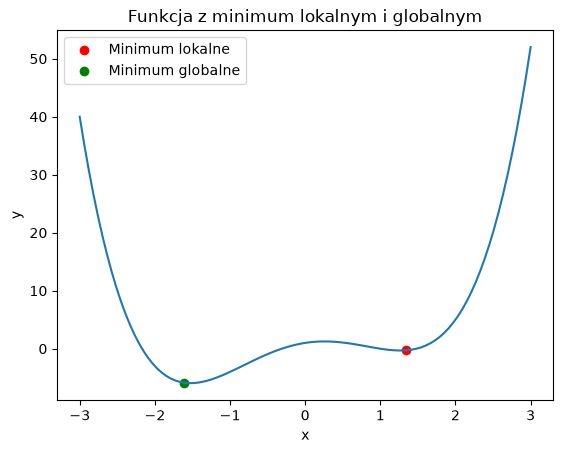

In [5]:
plt.plot(x, y)
plt.scatter(x_min_local, y_min_local, color="red", label="Minimum lokalne")
plt.scatter(x_min_global, y_min_global, color="green", label="Minimum globalne")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Funkcja z minimum lokalnym i globalnym")
plt.legend()

plt.show()

## Wyznaczanie gradientów

Ogólny algorytm optymalizacji gradientowej (ang. gradient descent) opiera się na twierdzeniu Taylora o właściwościach iloczynu skalarnego, które wyznacza dla dowolnego punktu (wektora parametrów) funkcji kosztu kierunek przeciwny do gradientu ($−∇f(x)$) i w ten sposób wskazuje kierunek najszybszego spadku funkcji. Mówiąc prościej, gradient wyznacza kierunek najszybszego wzrostu funkcji w danym punkcie. Poruszanie się w jego przeciwnym kierunku pozwala podążać ku minimum. Warto jednak zauważyć, że każda funkcja poddawana optymalizacji gradientowej musi jednak spełniać dwie najważniejsze własności: musi być ciągła oraz różniczkowalna w każdym punkcie.

### Algorytm optymalizacji gradientowej

1. Szukamy punktu $x^* \in \R^n$, który minimalizuje funkcję kosztu $f \colon \R^n \rightarrow \R: x^* = \text{argmin}_{x \in \R^n} f(x)$
2. Inicjalizujemy:
   1. punkt początkowy ($x^{(0)} \in \R^n$),
   2. wartość hiperparametru uczenia ($\alpha$),
   3. tolerancję uznania zbieżności ($\epsilon$) lub maksymalną liczbę iteracji ($K$).
3. Dla $k = 0...K$
   1. dla aktualnego punktu $x^(k)$ wyznaczamy gradient skalarny (dla funkcji jednoparametrycznej): $J'(f(x))$ lub bardziej ogólnie - wektor gradientów: $\nabla f(x^{(k)}) = \left[ \frac{\delta f(x^{(k)})}{\delta x_1}, \frac{\delta f(x^{(k)})}{\delta x_2}, ..., \frac{\delta f(x^{(k)})}{\delta x_n} \right]^T$
   2. sprawdzamy warunek stopu (uznanie zbieżności) jeżeli $x^* \approx x^{(k)}$:
      1. norma gradientu jest niewielka: $|| \nabla f(x^{(k)}) || < \epsilon$ lub/oraz,
      2. występuje niewielka różnica wartości między wartościami funkcji kosztu dla sąsiednich punktów: $|f(x^{(k+1)})| - f(x^{(k)}) < \epsilon$ lub/oraz,
      3. osiągnięto limit iteracji: $k \geq K$;
   3. aktualizujemy parametry w kierunku przeciwnym do gradientu: $x^{(k+1)} = x^{(k)} - \alpha_k \cdot \nabla f(x^{(k)})$.

### Symulacja optymalizacji gradientowej z różnymi wariantami hiperparametru uczenia

Poniższy przykład zawiera rozszerzenie poprzedniej wizualizacji o przykłady wyszukiwania minimów funkcji kosztu z wykorzystaniem gradientów oraz różnych wariantów kroków uczenia.

Definiujemy pochodną jednoparametrycznej funkcji kosztu: $J'(x) = 4x^3 - 8x + 2$ jako osobną funkcję.

In [6]:
def df(x: float) -> float:
    return 4 * x**3 - 8 * x + 2

Symulacja spadku gradientowego jako trajektoria kolejnych wartości funkcji.

In [7]:
def gradient_descent(x_start: float, lr: float, steps: int) -> np.ndarray:
    trajectory = [x_start]
    x = x_start
    for _ in range(steps):
        x = x - lr * df(x)
        trajectory.append(x)

    return np.array(trajectory)

Parametry symulacji róznych punktów startowych oraz wartości współczynnika uczenia.

In [8]:
scenarios = [
    {
        "x0": -2.3,
        "lr": 0.04,
        "color": "green",
        "label": "1. Prawidłowa zbieżność (minimum globalne)",
    },
    {
        
        "x0": 1.0,
        "lr": 0.05,
        "color": "orange",
        "label": "2. Utknięcie w minimum lokalnym",
    },
    {
        "x0": -2.1,
        "lr": 0.1,
        "color": "red",
        "label": "3. Przestrzelenie minimum (zbyt duży krok)",
    },
]

Wizualizacja pełnej symulacji.

In [9]:
x_vals = np.linspace(-2.5, 2.3, 500)
y_vals = target_fn(x_vals)

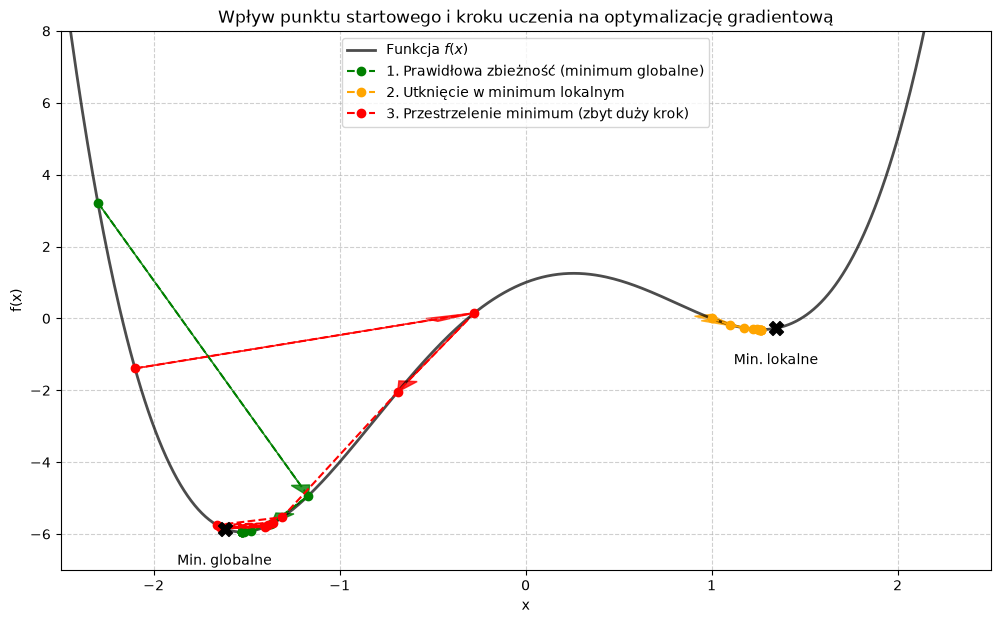

In [10]:
plt.figure(figsize=(12, 7))
plt.plot(x_vals, y_vals, "k-", linewidth=2, alpha=0.7, label="Funkcja $f(x)$")

# Rysowanie trajektorii oraz wektorów gradientu dla każdego scenariusza
for sc in scenarios:
    traj_x = gradient_descent(sc["x0"], sc["lr"], steps=10)
    traj_y = target_fn(traj_x)

    # Rysowanie punktów i linii łączącej kroki
    plt.plot(
        traj_x,
        traj_y,
        "o--",
        color=sc["color"],
        linewidth=1.5,
        markersize=6,
        label=sc["label"],
    )

    # Rysowanie wektorów gradientu (strzałek) dla pierwszych 2 kroków
    for i in range(2):
        x_i = traj_x[i]
        y_i = traj_y[i]
        dx = -sc["lr"] * df(x_i)  # Krok w kierunku przeciwnym do gradientu
        dy = target_fn(x_i + dx) - y_i

        plt.arrow(
            x_i,
            y_i,
            dx,
            dy,
            head_width=0.1,
            head_length=0.3,
            fc=sc["color"],
            ec=sc["color"],
            length_includes_head=True,
            alpha=0.8,
        )
# Adnotacje minimów
plt.scatter(
    [x_min_local, x_min_global],
    [target_fn(x_min_local), target_fn(x_min_global)],
    color="black",
    s=100,
    zorder=5,
    marker="X",
)
plt.text(
    x_min_local, target_fn(x_min_local) - 1, "Min. lokalne", horizontalalignment="center"
)
plt.text(
    x_min_global, target_fn(x_min_global) - 1, "Min. globalne", horizontalalignment="center"
)

plt.title(
    "Wpływ punktu startowego i kroku uczenia na optymalizację gradientową"
)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.xlim(-2.5, 2.5)
plt.ylim(-7, 8)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper center")

plt.show()

## Popularne zastosowania optymalizacji gradientowej

Optymalizacja gradientowa jest najczęściej obecnie stosowana wszędzie tam, gdzie mamy do czynienia z wieloparametrycznymi funkcjami kosztu.

1. Uczenie maszynowe: regresja liniowa/ nieliniowa/ logistyczna, SVM, wzmacnianie gradientowe, sieci neuronowe (propagacja wsteczna) poprzez minimalizację funkcji błędu.
2. Inżynieria: optymalizacja parametrów konstrukcyjnych.
3. Finanse: optymalizacja portfela inwestycyjnego lub analizy ryzyka.

## Optymalizacja gradientowa w praktyce

### Optymalizacja funkcji wielomianowej

In [11]:
from scipy.optimize import minimize

Funkcja kosztu: $f(x, y, z, v, t) = (x - 3)^5 + (y + 10)^4 + z^3 - (v+40)^2 + 4.5t$

In [12]:
def cost_fn(params: list) -> float:
    x, y, z, v, t = params
    return (x - 3) ** 5 + (y + 10) ** 4 + z ** 3 - (v + 40) ** 2 + 4.5 * t

Funkcja wyznaczająca gradient funkcji kosztu: $\nabla f = \left[ \frac{\delta f}{\delta x}, \frac{\delta f}{\delta y}, \frac{\delta f}{\delta z}, \frac{\delta f}{\delta v}, \frac{\delta f}{\delta t} \right]$:
- $\frac{\delta f}{\delta x} = 5(x - 3)^4$
- $\frac{\delta f}{\delta y} = 4(y + 10)^3$
- $\frac{\delta f}{\delta z} = 3z^2$
- $\frac{\delta f}{\delta v} = -2(v + 40)$
- $\frac{\delta f}{\delta t} = 4.5$

In [13]:
def grad_cost_fn(params: list) -> np.ndarray:
    x, y, z, v, t = params

    df_dx = 5 * (x - 3) ** 4
    df_dy = 4 * (y + 10) ** 3
    df_dz = 3 * (z**2)
    df_dv = -2 * (v + 40)
    df_dt = 4.5

    return np.array([df_dx, df_dy, df_dz, df_dv, df_dt])

Wyznaczenie punktu początkowego oraz warunku stopu.

In [14]:
initial_point = [0., 0., 0., 0., 0.]
epsilon = 1e-4

Poszukiwanie minimum funkcji kosztu z wykorzystaniem metody `BGFS`.

In [15]:
result = minimize(cost_fn, initial_point, jac=grad_cost_fn, method="BFGS", tol=epsilon)

Minimum funkcji

In [18]:
result.fun.item()

-1.844107187317266e+20

Optymalne parametry

In [17]:
result.x

array([-11299.05020563,   -649.81358929,      0.        ,   1471.35680578,
          -82.61267439])

### Optymalizacja modelu regresji logistycznej

Celem przykładu będzie praktyczna demonstracja działania optymalizacji gradientowej w uczeniu maszynowym. Dla separowalnego liniowo dwuwymiarowego zbioru danych zostanie wykorzystana regresja logistyczna celem jego klasyfikacji. Przykład zilustruje, jak na przestrzeni kolejnych iteracji aktualizujących parametry modelu matematycznego, zmianie będzie ulegać zarówno wartość funkcji kosztu, jak i sama dokładność klasyfikacji.

Model regresji logistycznej wyznacza prawdopodobienstwo ($p$) zdarzenia, w którym dany obiekt należy do do pozytywnej klasy decyzyjnej, poprzez transformację liniowej kombinacji atrybutów ($x$) i parametrów ($w$) za pomocą funkcji sigmoidalnej $\sigma(z) \colon \hat{y} = p = \sigma(w^Tx + b) = \frac{1}{1 + e^{-(w^T x + b)}}$.

Jakość działania regresji logistycznej określana będzie za pomocą funkcji binarnej entropii krzyżowej (ang. binary cross-entropy - BCE), która nakłada na model karę logarytmiczną na model za błędne klasyfikacje: 
$BCE(y, \hat{y}) = -\left[ y ln(\hat{y}) + (1-y) ln(1 - \hat{y}) \right]$, co dla całego zbioru obiektów można uogólnić następująco: $J(\vec{y}, \vec{\hat{y}}) = -\frac{1}{N} \sum_{i=1}^{N} BCE(y_i, \hat{y}_i)$, gdzie:
- $y$ - wartość decyzji docelowej,
- $\hat{y}$ - prawdopodobieństwo decyzji zwrócone przez model,
- $N$ - liczba obiektów w zbiorze danych.

W tym przypadku BCE będzie pełniła rolę funkcji kosztu. Minimalizacja błędu klasyfikacji doprowadzi model do coraz lepszych przewidywań.

In [26]:
from IPython.display import HTML
import matplotlib.animation as animation
import torch
import torch.nn as nn

In [12]:
np.random.seed(42)

Generowanie 40-elementowego zbioru danych, gdzie klasa 0 znajdzie się w lewym-dolnym rogu, a klasa 1 - w prawym-górnym.

In [13]:
X_raw = np.random.uniform(-4, 4, (200, 2))
margin = 0.5

In [14]:
x0 = X_raw[X_raw[:, 0] + X_raw[:, 1] < -margin][:40]
x1 = X_raw[X_raw[:, 0] + X_raw[:, 1] > margin][:40]

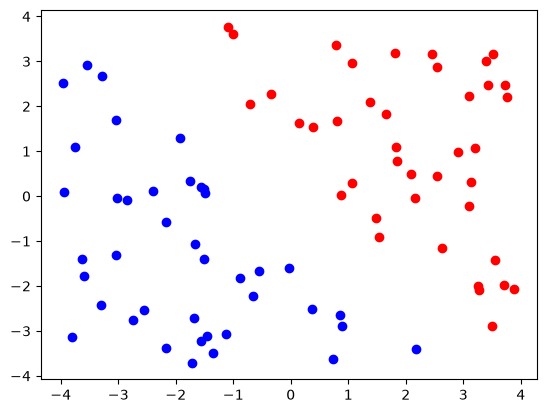

In [15]:
plt.scatter(x0[:, 0], x0[:, 1], color="blue", label="Klasa 0",)
plt.scatter(x1[:, 0], x1[:, 1], color="red", label="Klasa 1")
plt.show()

Przygotowanie zbioru danych do formy oczekiwanej przez PyTorch

In [16]:
X_data = np.vstack((x0, x1))
y_data = np.hstack((np.zeros(40), np.ones(40)))

X_tensor = torch.tensor(X_data, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1)

Definicja jednowarstwowej sieci neuronowej z logistyczną funkcją wyjścia (odpowiednik trywialnej regresji logistycznej)

In [17]:
class LogisticRegressionModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x: float) -> torch.Tensor:
        return torch.sigmoid(self.linear(x))

Utworzenie modelu oraz funkcji kosztu jako Binarna Entropia Krzyżowa

In [18]:
K = 40
lr = 0.2

In [19]:
model = LogisticRegressionModel()
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

Pętla optymalizacyjna

In [20]:
history_loss = []
history_weights = []
history_bias = []

W każdej iteracji:
- generujemy wyjście, czyli klasy decyzyjne dla każdego punktu
- wyznaczamy wartość funkcji kosztu
- wyznaczamy wartości gradientów
- aktualizujemy parametry

In [21]:
for epoch in range(K):
    optimizer.zero_grad()
    outputs = model(X_tensor)  # wyjścia z regresji logistycznej
    loss = criterion(outputs, y_tensor)  # wartość funkcji kosztu
    loss.backward()  # wartości gradientów
    optimizer.step()  # aktualizacja parametrów

    history_loss.append(loss.item())
    history_weights.append(model.linear.weight.data.numpy().copy())
    history_bias.append(model.linear.bias.data.numpy().copy())

Wizualizacja

In [22]:
def update(epoch: int) -> None:
    ax1.clear()
    ax2.clear()

    # odtworzenie wag dla danej iteracji
    w = history_weights[epoch][0]
    b = history_bias[epoch][0]

    # wyznaczenie prawdopodobieństw na siatce dla tła
    Z = torch.sigmoid(grid_tensor @ torch.tensor(w) + b).numpy()
    Z = Z.reshape(xx.shape)

    # wykres 1: Granica decyzyjna i punkty
    ax1.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.6)
    ax1.contour(
        xx, yy, Z, levels=[0.5], colors="k", linewidths=2
    )  # Granica p=0.5
    ax1.scatter(
        x0[:, 0], x0[:, 1], color="blue", edgecolor="k", label="Klasa 0"
    )
    ax1.scatter(
        x1[:, 0], x1[:, 1], color="red", edgecolor="k", label="Klasa 1"
    )
    ax1.set_title(f"Epoka {epoch+1}/{K} - Granica decyzyjna")
    ax1.set_xlabel("$X_1$")
    ax1.set_ylabel("$X_2$")
    ax1.legend(loc="upper left")

    # wykres 2: Spadek funkcji kosztu
    ax2.plot(
        range(1, epoch + 2), history_loss[: epoch + 1], "r-o", linewidth=2
    )
    ax2.set_xlim(0, K + 1)
    ax2.set_ylim(0, max(history_loss) * 1.1)
    ax2.set_title(f"Koszt (BCE Loss): {history_loss[epoch]:.4f}")
    ax2.set_xlabel("Epoka")
    ax2.set_ylabel("Loss")
    ax2.grid(True, linestyle="--", alpha=0.5)

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
)
grid_tensor = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32
)

ani = animation.FuncAnimation(
    fig, update, frames=K, interval=250, repeat=False
)
plt.tight_layout()
plt.close()
HTML(ani.to_jshtml())

/Users/tomek/dev/pg/optymalizacja_chemia/.venv/lib/python3.13/site-packages/matplotlib/animation.py:916: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
